## Imports

In [2]:
%load_ext autoreload
%autoreload 2

import ast
import random as rd
rd.seed(639)

from copy import deepcopy

import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats

from cca_zoo.linear import CCA
from cca_zoo.sparse import IPLSCCA
from matplotlib.colors import to_rgba
from matplotlib import pyplot as plt
import matplotlib.transforms as mtransforms

from cv_iplscca import nested_cv_scca_ipls, teste_permutacao
from testes import mardia_test, pillai_test

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Converte os dados do json em formas úteis

In [ ]:
""";
data = []

with open("checkpoint1.jsonl") as file:
    for i in file:
        data.append(i)

with open("checkpoint2.jsonl") as file:
    for i in file:
        data.append(i)

with open("checkpoint3.jsonl") as file:
    for i in file:
        data.append(i)

with open("checkpoint4.jsonl") as file:
    for i in file:
        data.append(i)

new_data = list(map(lambda artigo: artigo.strip().replace("null,", "\"nan\",").replace("null", "\"nan\""), data))
dirty_rows = list(map(lambda artigo: artigo["rows"][0], map(lambda artigo: ast.literal_eval(artigo), new_data)))
df = pd.DataFrame.from_dict(dirty_rows)
df = df.drop(columns="experiment_id")

df.to_csv("mega_vapo.csv")
""";

In [ ]:
df = pd.read_csv("mega_vapo.csv")
df = df.drop(columns="Unnamed: 0")

In [ ]:
for i in df:
    print(i)

Se o abstract não cita uma morfologia específica, assumimos que é nanoflake
Se o abstract não cita uma espessura específica, assumimos que é bulk

In [ ]:
df.loc[df["structure_format"].apply(lambda x: isinstance(x, float)), "structure_format"] = "['nanoflake']"
df.loc[df["num_sheets"].apply(lambda x: isinstance(x, float)), "num_sheets"] = "['bulk']"

## Amostragem dos dados para comparação manual de desempenho

A amostragem ocorreu no meio da coleta de dados, assim, apesar do mesmo random_state, os abstracts serão diferentes

In [ ]:
"""
amostras = df.sample(n=30, random_state=639)
ids_amostras = [(index, artigo["doc_id"]) for (index, artigo) in amostras.iterrows()]

with open('nomes_amostras.txt', 'w') as fp:
    for (idx, idr) in ids_amostras:
        fp.write(str(idx) + ":   " + str(idr))
        fp.write("\n")
        fp.write("\n")

df_brutos = pd.read_excel("raw_abstracts.xlsx")
selecionados = df.iloc[list(map(lambda x: x[0], ids_amostras[:15]))]["doc_id"].to_list()

abstracts_inteiros = []

for authors in selecionados:

    print(df_brutos[df_brutos["Authors"] == authors]["Authors"].to_list())
    print()

    
    abstracts_inteiros.append(
        (
            df_brutos[df_brutos["Authors"] == authors]["Authors"].to_list(),
            df_brutos[df_brutos["Authors"] == authors]["Abstract"].to_list()
        )
    )
abstracts_inteiros

with open('meus_autores.txt', 'w') as fp:
    for authors, abstracts in abstracts_inteiros:
        fp.write(authors + ":   " + abstracts)
        fp.write("\n")
        fp.write("\n")
""";

## Eliminação das colunas quase vazias

In [139]:
per_category_absence_values = [len(df) - df[each_column].count() for each_column in df.columns[1:]]
per_category_absence_keys = df.columns[1:]
per_category_absence = {
    key: round(int(value) / len(df), 2) 
    for value, key in zip(per_category_absence_values, per_category_absence_keys)
}
per_category_absence

{'synthesis_methods': 0.41,
 'synthesis_direction': 0.98,
 'post_synthesis_modifications': 0.79,
 'synthesis_engineering': 0.91,
 'num_sheets': 0.0,
 'structure_format': 0.0,
 'specific_applications': 0.11,
 'general_applications': 0.16}

In [140]:
demi_df = df.drop(columns=["synthesis_direction", "synthesis_engineering"])

In [141]:
view_new_absence = dict(per_category_absence)

del view_new_absence["synthesis_direction"]
del view_new_absence["synthesis_engineering"]

view_new_absence

{'synthesis_methods': 0.41,
 'post_synthesis_modifications': 0.79,
 'num_sheets': 0.0,
 'structure_format': 0.0,
 'specific_applications': 0.11,
 'general_applications': 0.16}

## Transformação dos dados em binários

In [142]:
qnt_abstracts = demi_df.shape[0]

In [143]:
datadict = {
        "doc_id": [0]*qnt_abstracts,
        "autoclave_method": [0]*qnt_abstracts,
        "hydrothermal": [0]*qnt_abstracts,
        "solvothermal": [0]*qnt_abstracts,
        "mechanical_exfoliation": [0]*qnt_abstracts,
        "sticky_tape": [0]*qnt_abstracts,
        "ball_milling": [0]*qnt_abstracts,
        "chemical_exfoliation": [0]*qnt_abstracts,
        "intercalation_exfoliation": [0]*qnt_abstracts,
        "electrochemical_exfoliation": [0]*qnt_abstracts,
        "chemical_vapor_deposition": [0]*qnt_abstracts,
        "microwave_driven_exfoliation": [0]*qnt_abstracts,
        "liquid_phase_exfoliation": [0]*qnt_abstracts,
        "thermal_synthesis": [0]*qnt_abstracts,
        "heteroatom_doping": [0]*qnt_abstracts,
        "heterojunction": [0]*qnt_abstracts,
        "support": [0]*qnt_abstracts,
        "phase_adjustment": [0]*qnt_abstracts,
        "sulfur_vacancy": [0]*qnt_abstracts,
        "molybdenum_vacancy": [0]*qnt_abstracts,
        "metal_clusters": [0]*qnt_abstracts,
        "bulk": [0]*qnt_abstracts,
        "few_layer": [0]*qnt_abstracts,
        "monolayer": [0]*qnt_abstracts,
        "double_layer": [0]*qnt_abstracts,
        "ribbon": [0]*qnt_abstracts,
        "nanoflower": [0]*qnt_abstracts,
        "nanoflake": [0]*qnt_abstracts,
        "nanoparticle": [0]*qnt_abstracts,
        "nanotube": [0]*qnt_abstracts,
        "quantum_dot": [0]*qnt_abstracts,
        "her": [0]*qnt_abstracts,
        "oer": [0]*qnt_abstracts,
        "nrr": [0]*qnt_abstracts,
        "co2rr": [0]*qnt_abstracts,
        "pollutants": [0]*qnt_abstracts,
        "electrocatalysis": [0]*qnt_abstracts,
        "photocatalysis": [0]*qnt_abstracts
    }

renames = {
    "doc_id": "doc_id",
    "autoclave_method": "S_autoclave_method",
    "hydrothermal": "S_hydrothermal",
    "solvothermal": "S_solvothermal",
    "mechanical_exfoliation": "S_mechanical_exfoliation",
    "sticky_tape": "S_sticky_tape",
    "ball_milling": "S_ball_milling",
    "chemical_exfoliation": "S_chemical_exfoliation",
    "intercalation_exfoliation": "S_intercalation_exfoliation",
    "electrochemical_exfoliation": "S_electrochemical_exfoliation",
    "chemical_vapor_deposition": "S_chemical_vapor_deposition",
    "microwave_driven_exfoliation": "S_microwave_driven_exfoliation",
    "liquid_phase_exfoliation": "S_liquid_phase_exfoliation",
    "thermal_synthesis": "S_thermal_synthesis",
    "heteroatom_doping": "PSM_heteroatom_doping",
    "heterojunction": "PSM_heterojunction",
    "support": "PSM_support",
    "phase_adjustment": "PSM_phase_adjustment",
    "sulfur_vacancy": "PSM_sulfur_vacancy",
    "molybdenum_vacancy": "PSM_molybdenum_vacancy",
    "metal_clusters": "PSM_metal_clusters",
    "bulk": "NS_bulk",
    "few_layer": "NS_few_layer",
    "monolayer": "NS_monolayer",
    "double_layer": "NS_double_layer",
    "ribbon": "SF_ribbon",
    "nanoflower": "SF_nanoflower",
    "nanoflake": "SF_nanoflake",
    "nanoparticle": "SF_nanoparticle",
    "nanotube": "SF_nanotube",
    "quantum_dot": "SF_quantum_dot",
    "her": "SA_her",
    "oer": "SA_oer",
    "nrr": "SA_nrr",
    "co2rr": "SA_co2rr",
    "pollutants": "SA_pollutants",
    "electrocatalysis": "GA_electrocatalysis",
    "photocatalysis": "GA_photocatalysis"
}

In [144]:
datadictator = deepcopy(datadict)

for each_column in demi_df.columns:

    if each_column == "doc_id":

        for i, each_row in enumerate(demi_df["doc_id"].to_list()):

            datadictator["doc_id"][i] = each_row
        
        continue
    
    for i, each_row in enumerate(demi_df[each_column].to_list()):

        if isinstance(each_row, float): # float("nan")
            continue
        else:
            each_row = ast.literal_eval(each_row)
            
        if isinstance(each_row, list):
            for classification in each_row:
                datadictator[classification.lower()][i] = 1
                
        else:
            print("Coluna:", each_column)
            print("Linha:", each_row)
            print("Linha:", type(each_row))
            raise TypeError("O df não está seguindo o padrão previsto!")

In [145]:
binary_df = pd.DataFrame(datadictator)

In [146]:
binary_df

,doc_id,autoclave_method,hydrothermal,solvothermal,mechanical_exfoliation,sticky_tape,ball_milling,chemical_exfoliation,intercalation_exfoliation,electrochemical_exfoliation,...,nanoparticle,nanotube,quantum_dot,her,oer,nrr,co2rr,pollutants,electrocatalysis,photocatalysis
0,"Xu, ZW; Liu, XY; Yao, K; Ren, YC; Li, JY; Shen...",0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
1,"Pan, C; Dong, CL; Chen, WS; Qian, SH; Yin, JX;...",0,1,0,0,0,0,1,0,0,...,0,0,1,1,0,0,0,0,0,0
2,"Li, TT; Wang, ZH; Liu, CC; Tang, CM; Wang, XK;...",0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
3,"Peng, H; Lu, J; Wu, CX; Yang, ZX; Chen, H; Son...",0,1,0,0,0,0,0,0,0,...,1,0,0,0,0,0,1,0,1,1
4,"Singh, J; Singh, R; Duhan, P; Mann, Y; Manna, ...",0,1,0,0,0,0,0,0,0,...,1,1,0,1,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1922,"Panghal, A; Sahoo, D; Deepak, D; Deshmukh, S; ...",0,1,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
1923,"Samarasinghe, LV; Muthukumaran, S; Baskaran, K",0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,1
1924,"Chen, GP; Ding, N; Li, F; Fan, YZ; Luo, YH; Li...",0,1,1,0,0,0,0,1,0,...,1,0,0,1,0,0,0,0,0,1
1925,"Johari, MH; Sirat, MS; Mohamed, MA; Nasir, SNF...",0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0


## CCA (esparso)
**Comparação entre post_synthesis_modifications + num_sheets + structure_format com specific_application**
Para investigar a relação entre as características físicas do material e a aplicação apontada

### Seleção dos abstracts com registros completos dos 4 conjuntos de dados

### pre_canonical_df = binary_df[
    (~demi_df["post_synthesis_modifications"].isna()) 
    & (~demi_df["num_sheets"].isna()) 
    & (~demi_df["structure_format"].isna()) 
    & (~demi_df["specific_applications"].isna()) 
    ]

list(pre_canonical_df.columns)

In [147]:
psm_indexes = list(range(14, 20+1))
ns_indexes = list(range(21, 24+1))
sf_indexes = list(range(25, 30+1))
sa_indexes = list(range(31, 35+1))

In [148]:
first_canonical_df = pre_canonical_df.iloc[:, psm_indexes+ns_indexes+sf_indexes]
second_canonical_df = pre_canonical_df.iloc[:, sa_indexes]

print("Quantidade de abstracts considerados:", first_canonical_df.shape[0])

Quantidade de abstracts considerados: 375


### Comparação da presença de cada classe

In [149]:
psm_sum = int(first_canonical_df.iloc[:, map(lambda x: x-14, psm_indexes)].sum().sum())
ns_sum = int(first_canonical_df.iloc[:, map(lambda x: x-14, ns_indexes)].sum().sum())
sf_sum = int(first_canonical_df.iloc[:, map(lambda x: x-14, sf_indexes)].sum().sum())
sa_sum = int(second_canonical_df.iloc[:, map(lambda x: x-31, sa_indexes)].sum().sum())

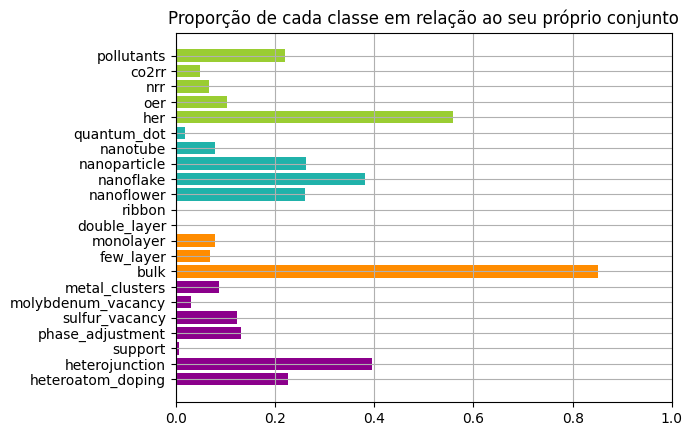

In [151]:
fig, ax = plt.subplots()

for i in psm_indexes+ns_indexes+sf_indexes+sa_indexes:

    if i in psm_indexes:
        colore = "darkmagenta"
        proportion = int(first_canonical_df.iloc[:, i-14].sum()) / psm_sum
        
    elif i in ns_indexes:
        colore = "darkorange"
        proportion = int(first_canonical_df.iloc[:, i-14].sum()) / ns_sum
        
    elif i in sf_indexes:
        colore = "lightseagreen"
        proportion = int(first_canonical_df.iloc[:, i-14].sum()) / sf_sum
        
    elif i in sa_indexes:
        colore = "yellowgreen"
        proportion = int(second_canonical_df.iloc[:, i-31].sum()) / sa_sum

    else:
        raise TypeError("Uopa!")

    ax.barh(y=i-13, width=proportion, height=0.8, color=colore)

ax.set_yticks(
    ticks=range(1, 23),
    labels=list(first_canonical_df.columns) + list(second_canonical_df.columns)
)
ax.set_xlim(0, 1)

ax.grid()
ax.set_title("Proporção de cada classe em relação ao seu próprio conjunto")

fig.savefig("prop_classe_cca.png", dpi=500, bbox_inches="tight")
plt.show()

Posto que não há registros de "ribbon" nem de "double_layer", retiraremos essas colunas do dataset

In [152]:
first_canonical_df = first_canonical_df.drop(columns=["ribbon", "double_layer"])
second_canonical_df = second_canonical_df

### CCA e testes de hipótese

1. Mardia (dados originais) → decide MVN sim/não
2. Roda o CCA
3. Testa significância das correlações canônicas:
   Wilks e Rao + Pillai

O nível de confiança será 95%!

In [22]:
NIVEL_CONFIANCA = 0.95
SIGNIFICANCIA = 1 - NIVEL_CONFIANCA

#### Teste de normalidade multivariada de Mardia
Mardia, K. V. (1970) - https://doi.org/10.1093/biomet/57.3.519

Código por Quillan86 - https://github.com/quillan86/mvn-python/blob/master/mvn.py

In [23]:
_, _, p_valor_assimetria, p_valor_curtose = mardia_test(first_canonical_df.join(second_canonical_df).to_numpy())

In [24]:
print("P-valor de Assimetria:", float(p_valor_assimetria))
print("P-valor de Curtose:", float(p_valor_curtose))

P-valor de Assimetria: 0.0
P-valor de Curtose: 0.0


O teste é bem extremo para não contrariar a não normalidade dos dados :(

#### CCA linear

In [42]:
model_CCA = CCA(latent_dimensions=5).fit([first_canonical_df, second_canonical_df])
score_comum_f, score_comum_a = model_CCA.transform([first_canonical_df, second_canonical_df])

#### Traço de Pillai
Adaptado pelo Claude a partir do pacote de R "CCP"

In [43]:
rho_pillai = np.array(
    [np.corrcoef(score_comum_f[:, i], score_comum_a[:, i])[0, 1] for i in range(score_comum_f.shape[1])]
)

In [44]:
rho_pillai

array([0.413588  , 0.26124301, 0.2251087 , 0.15759653, 0.0985479 ])

In [45]:
p_valores = []

for i in range(1, 5+1):
    p_valor_da_var_canon = pillai_test(rho_pillai, N=375, p=15, q=5, rhostart=i)
    p_valores.append(round(float(p_valor_da_var_canon["p_value"]), 6))

In [46]:
p_valores

[0.000381, 0.423533, 0.792099, 0.970261, 0.981134]

Apenas com o 1° eixo canônico podemos rejeitar a hipótese nula do Pillai's de que os dados não têm significância de correlação multivariada. Ou seja, apenas o 1° eixo representa provavelmente algo que não seja ruído.

#### IPLSCCA
Sparse Canonical Correlation Analysis via Iterative Partial Least Squares - 10.1111/biom.13043

Código do CCA do módulo de Python; CV com código feito pelo Claude

O teste de Pillai feito anteriormente foi para o CCA linear. Os nossos datasets vêm de variáveis multilabel e é esparso. É mais efetivo utilizar o IPLSCCA.

Mas como estaremos impondo uma nova restrição matemática de fruto hiperparamétrico, estaremos reformulando a distribuição original dos dados. Um teste de hipótese tornaria nossa análise circular (doi:10.1038/nn.2303), então faremos 2 coisas:

1. A escolha do hiperparâmetro será validade por CV aninhado para verificarmos qual é o melhor valor para obter generalização. Ou seja, respondemos à pergunta *"Caso criássemos uma nova distribuição dos dados para a nossa análise por meio de novas novas imposições matemáticas, com 375 instâncias de dados, os nossos resultados se aproximam com o resultado de toda a distribuição?*"

2. Testaremos a significância dos dados, que agora não possui teste de hipótese pronto. A pergunta aqui é: "Na nova distribuição, a significância que observamos corresponde bem aos dados ou representa mais o ruído aleatório?" Para respondermos isso, podemos justamente aleatorizar os dados e verificar a cada vez a correlação. O teste de hipótese será assim: *H0 = a correlação que identificamos nos dados reais sob IPLSCCA é significativa.*. Testaremos isso assim: embaralhamos os dados de Y e fazemos a mesma pipeline matemática; quanto menor a proporção de tentativas aleatórias que superam a correlação observada dos dados reais, mais provável que a nossa pipeline matemática não esteja se ajustando à nossa hipótese (de significância da correlação).

##### Fazendo um teste de CV aninhado (o melhor valor de alpha é utilizado para fazer CV no conjunto total)

In [47]:
alphas = [0.01, 0.05, 0.1, 0.2, 0.5, 0.7, 1.0]

In [48]:
resultados = nested_cv_scca_ipls(
    first_canonical_df.to_numpy(),
    second_canonical_df.to_numpy(),
    alphas,
    n_outer=15,
    n_inner=15,
    l1_ratio=0.0,
    random_state=639
)

KeyboardInterrupt: 

In [ ]:
resultados

Os resultados indicam que utilizar $\alpha = 1$ possui alguma capacidade de generalização caso o dataset seja expandido.

##### Testando a significância da correlação com IPLSCCA

In [38]:
resultado_teste_iplscca = teste_permutacao(
    first_canonical_df.to_numpy(),
    second_canonical_df.to_numpy(), 
    alphas, 
    B=500, 
    l1_ratio=0.0, 
    random_state=639
)

Round: 0
Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
Round: 11
Round: 12
Round: 13
Round: 14
Round: 15
Round: 16
Round: 17
Round: 18
Round: 19
Round: 20
Round: 21
Round: 22
Round: 23
Round: 24
Round: 25
Round: 26
Round: 27
Round: 28
Round: 29
Round: 30
Round: 31
Round: 32
Round: 33
Round: 34
Round: 35
Round: 36
Round: 37
Round: 38
Round: 39
Round: 40
Round: 41
Round: 42
Round: 43
Round: 44
Round: 45
Round: 46
Round: 47
Round: 48
Round: 49
Round: 50
Round: 51
Round: 52
Round: 53
Round: 54
Round: 55
Round: 56
Round: 57
Round: 58
Round: 59
Round: 60
Round: 61
Round: 62
Round: 63
Round: 64
Round: 65
Round: 66
Round: 67
Round: 68
Round: 69
Round: 70
Round: 71
Round: 72
Round: 73
Round: 74
Round: 75
Round: 76
Round: 77
Round: 78
Round: 79
Round: 80
Round: 81
Round: 82
Round: 83
Round: 84
Round: 85
Round: 86
Round: 87
Round: 88
Round: 89
Round: 90
Round: 91
Round: 92
Round: 93
Round: 94
Round: 95
Round: 96
Round: 97
Round: 98
Round: 99
Round: 100

In [39]:
resultado_teste_iplscca

{'rho_obs': np.float64(0.4118171749318986),
 'rho_permutados': array([0.28600675, 0.26518636, 0.26333948, 0.2557293 , 0.25201096,
        0.25993223, 0.28866714, 0.3335008 , 0.26919286, 0.20510275,
        0.22618002, 0.32202868, 0.32060687, 0.28630377, 0.2457812 ,
        0.33065617, 0.24787744, 0.32972388, 0.28543619, 0.23523391,
        0.24363561, 0.32871498, 0.2490292 , 0.27878078, 0.33435457,
        0.32572397, 0.29145609, 0.27730975, 0.29189621, 0.33039486,
        0.29535552, 0.25270317, 0.31071311, 0.27924478, 0.21131128,
        0.31738509, 0.23733383, 0.3131641 , 0.27427597, 0.2668838 ,
        0.28307413, 0.37313344, 0.28235985, 0.26007577, 0.26198049,
        0.33218207, 0.3059536 , 0.25047631, 0.25684919, 0.32073579,
        0.21387851, 0.25461899, 0.29430583, 0.35514476, 0.31294313,
        0.26655009, 0.29647211, 0.30071829, 0.25498245, 0.2508636 ,
        0.26581159, 0.2880667 , 0.30505031, 0.24681579, 0.28816286,
        0.28404977, 0.28371595, 0.285089  , 0.2957223 

O resultado anterior corresponde à comparação da 1a dimensão. Agora para a 2a dimensão (desejada)

**p_valor contra a significância do 1o vetor canônico = 0.002**

In [51]:
resultado_teste_iplscca_DOIS = teste_permutacao(
    first_canonical_df.to_numpy(),
    second_canonical_df.to_numpy(), 
    alphas, 
    B=500, 
    l1_ratio=0.0, 
    random_state=639,
    __dim=3
)

Round: 0
Round: 1
Round: 2
Round: 3
Round: 4
Round: 5
Round: 6
Round: 7
Round: 8
Round: 9
Round: 10
Round: 11
Round: 12
Round: 13
Round: 14
Round: 15
Round: 16
Round: 17
Round: 18
Round: 19
Round: 20
Round: 21
Round: 22
Round: 23
Round: 24
Round: 25
Round: 26
Round: 27
Round: 28
Round: 29
Round: 30
Round: 31
Round: 32
Round: 33
Round: 34
Round: 35
Round: 36
Round: 37
Round: 38
Round: 39
Round: 40
Round: 41
Round: 42
Round: 43
Round: 44
Round: 45
Round: 46
Round: 47
Round: 48
Round: 49
Round: 50
Round: 51
Round: 52
Round: 53
Round: 54
Round: 55
Round: 56
Round: 57
Round: 58
Round: 59
Round: 60
Round: 61
Round: 62
Round: 63
Round: 64
Round: 65
Round: 66
Round: 67
Round: 68
Round: 69
Round: 70
Round: 71
Round: 72
Round: 73
Round: 74
Round: 75
Round: 76
Round: 77
Round: 78
Round: 79
Round: 80
Round: 81
Round: 82
Round: 83
Round: 84
Round: 85
Round: 86
Round: 87
Round: 88
Round: 89
Round: 90
Round: 91
Round: 92
Round: 93
Round: 94
Round: 95
Round: 96
Round: 97
Round: 98
Round: 99
Round: 100

In [52]:
resultado_teste_iplscca_DOIS

{'rho_obs': np.float64(0.12299370630606819),
 'rho_permutados': array([ 0.0973321 ,  0.09863993, -0.00450765,  0.11585845,  0.08188116,
         0.02094329,  0.17282743,  0.09258576,  0.14043255,  0.08066733,
         0.12824624,  0.14681811,  0.14207702,  0.05006484,  0.12423805,
         0.15376598,  0.07321457,  0.17920499,  0.18102385,  0.04717404,
         0.06854081,  0.08570896,  0.05747981,  0.1332448 ,  0.14773781,
         0.10102259,  0.11312928,  0.07249192,  0.09628138,  0.01158856,
         0.03732896,  0.11966224,  0.05350783,  0.1491321 ,  0.07785035,
         0.07449533,  0.12638656,  0.1414703 ,  0.04809637,  0.00879448,
        -0.01606454,  0.09406907,  0.14135218,  0.16880503,  0.07221886,
         0.0623082 ,  0.1529882 ,  0.06646812,  0.10348565,  0.06065508,
         0.15427153,  0.11015946,  0.17852951,  0.1556214 ,  0.10631696,
         0.06265011,  0.03762312,  0.13969835,  0.10725831,  0.07431676,
         0.0242359 ,  0.03986306,  0.09260298,  0.11839624,  

O p_valor do teste com o 2º vetor canônico foi $\approx 0.3$

### Violin plot de CCA e IPLSCCA

In [49]:
modelo_iplscca = IPLSCCA(latent_dimensions=1, alpha=1, l1_ratio=0, random_state=639)
fisicos_scores, aplicacoes_scores = modelo_iplscca.fit_transform([first_canonical_df, second_canonical_df])

In [50]:
model_CCA = CCA(latent_dimensions=1).fit([first_canonical_df, second_canonical_df])
score_comum_p, score_comum_a = model_CCA.transform([first_canonical_df, second_canonical_df])

In [51]:
# Projeção de cada objeto sobre o eixo canônico
proj_comum_f = score_comum_p[:, 0]
proj_comum_a = score_comum_a[:, 0]

proj_f = -fisicos_scores[:, 0]
proj_a = -aplicacoes_scores[:, 0]

In [52]:
dados_binarios_f = {
        column_f: first_canonical_df.iloc[:, f_idx] 
        for f_idx, column_f in enumerate(first_canonical_df.columns)
}

dados_binarios_a = {
        column_a: second_canonical_df.iloc[:, a_idx]
        for a_idx, column_a in enumerate(second_canonical_df.columns)
}

centroides_comuns_f = {
    rotulo: float(proj_comum_f[valores == 1].mean())
    for rotulo, valores in dados_binarios_f.items()
}

centroides_comuns_a = {
    rotulo: float(proj_comum_a[valores == 1].mean())
    for rotulo, valores in dados_binarios_a.items()
}

centroides_f = {
    rotulo: float(proj_f[valores == 1].mean())
    for rotulo, valores in dados_binarios_f.items()
}

centroides_a = {
    rotulo: float(proj_a[valores == 1].mean())
    for rotulo, valores in dados_binarios_a.items()
}

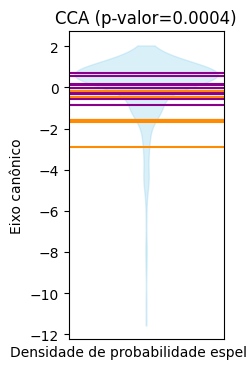

In [53]:
fig, ax = plt.subplots(figsize=(2, 4))

violino_comum = ax.violinplot(
    proj_comum_f+proj_comum_a,
    positions=[0], 
    vert=True,
    orientation="vertical",
    widths=0.5,
    showmeans=False,
    showextrema=False,
    showmedians=False,
    quantiles=None,
    points=375
)

"""ax.vlines(0, ymin=-1000, ymax=1000, color="steelblue", alpha=0.6)"""

# Define a cor de face para cada corpo do violino
for body in violino_comum["bodies"]:
    body.set_facecolor("skyblue")
    body.set_edgecolor("skyblue")

for centroide in centroides_comuns_f.values():
    ax.hlines(centroide, xmin=-1000, xmax=1000, color="darkmagenta")

for centroide in centroides_comuns_a.values():
    ax.hlines(centroide, xmin=-1000, xmax=1000, color="darkorange")

ax.set_xlim(-0.27, 0.27)
ax.set_xticks([])
ax.set_xlabel("Densidade de probabilidade espelhada")
    
ax.set_ylabel("Eixo canônico")
    
ax.set_title(f"CCA (p-valor={p_valores[0]:.4f})")

plt.show()

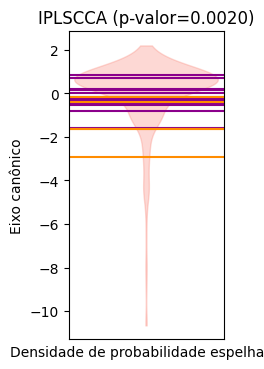

In [70]:
fig, ax = plt.subplots(figsize=(2, 4))

violino_comum = ax.violinplot(
    proj_f+proj_a,
    positions=[0], 
    vert=True,
    orientation="vertical",
    widths=0.5,
    showmeans=False,
    showextrema=False,
    showmedians=False,
    quantiles=None,
    points=375
)
'ax.vlines(0, ymin=-1000, ymax=1000, color="red", alpha=0.6)'

# Define a cor de face para cada corpo do violino
for body in violino_comum["bodies"]:
    body.set_facecolor("salmon")
    body.set_edgecolor("salmon")

for centroide in centroides_f.values():
    ax.hlines(centroide, xmin=-1000, xmax=1000, color="darkmagenta")

for centroide in centroides_a.values():
    ax.hlines(centroide, xmin=-1000, xmax=1000, color="darkorange")

ax.set_xlim(-0.27, 0.27)
ax.set_xticks([])
ax.set_xlabel("Densidade de probabilidade espelhada")
    
ax.set_ylabel("Eixo canônico")
    
ax.set_title(f"IPLSCCA (p-valor={resultado_teste_iplscca["p_valor"]:.4f})")
######### !!! O resultado do teste é reprodutível, mas demora, então utilizaremos o registro atual !!!

plt.show()

In [71]:
resultado_teste_iplscca = {"p_valor": 0.0020}

**p-valor = 0.0020**

In [58]:
r = np.corrcoef(proj_comum_f+proj_comum_a, proj_f+proj_a)[0, 1]

In [59]:
r

np.float64(0.9979029995647676)

In [61]:
r**2

np.float64(0.9958103965403605)

Ou seja, $R^2\approx0.996$

### Violin plot bidimensional

In [72]:
sorted_cc_f = dict(sorted(centroides_comuns_f.items(), key=lambda item: item[1]))
sorted_cc_a = dict(sorted(centroides_comuns_a.items(), key=lambda item: item[1]))

sorted_c_f = dict(sorted(centroides_f.items(), key=lambda item: item[1]))
sorted_c_a = dict(sorted(centroides_a.items(), key=lambda item: item[1]))

In [154]:
vcf_psm = np.array(
    [value for key, value in sorted_cc_f.items() if key in pre_canonical_df.columns[psm_indexes]]
)
classes_psm = [key for key in sorted_cc_f.keys() if key in pre_canonical_df.columns[psm_indexes]]

vcf_ns = np.array(
    [value for key, value in sorted_cc_f.items() if key in pre_canonical_df.columns[ns_indexes]]
)
classes_ns = [key for key in sorted_cc_f.keys() if key in pre_canonical_df.columns[ns_indexes]]

vcf_sf = np.array(
    [value for key, value in sorted_cc_f.items() if key in pre_canonical_df.columns[sf_indexes]]
)
classes_sf = [key for key in sorted_cc_f.keys() if key in pre_canonical_df.columns[sf_indexes]]

vca_sa = np.array(
    [value for key, value in sorted_cc_a.items() if key in pre_canonical_df.columns[sa_indexes]]
)
classes_sa = [key for key in sorted_cc_a.keys() if key in pre_canonical_df.columns[sa_indexes]]

In [74]:
vf_psm = np.array(
    [value for key, value in sorted_c_f.items() if key in pre_canonical_df.columns[psm_indexes]]
)
vf_ns = np.array(
    [value for key, value in sorted_c_f.items() if key in pre_canonical_df.columns[ns_indexes]]
)
vf_sf = np.array(
    [value for key, value in sorted_c_f.items() if key in pre_canonical_df.columns[sf_indexes]]
)
va_sa = np.array(
    [value for key, value in sorted_c_a.items() if key in pre_canonical_df.columns[sa_indexes]]
)

In [75]:
"""
v_c_f = np.log(np.array(list(centroides_comuns_f.values()))*10)
v_c_a = np.log(np.array(list(centroides_comuns_a.values()))*10)
v_f = np.log(np.array(list(centroides_f.values()))*10)
v_a = np.log(np.array(list(centroides_a.values()))*10)
""";

In [76]:
fillstyles_classe = ['full', 'left', 'bottom', 'right', 'none']

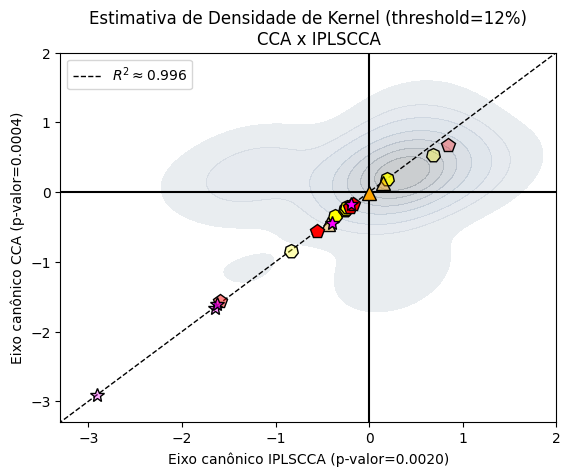

In [175]:
fig, ax = plt.subplots()

# Retas do 0
ax.hlines(0, -7, 7, color="black", alpha=1)
ax.vlines(0, -7, 7, color="black", alpha=1)

# densidade de fundo: onde as 375 amostras se concentram
sns.kdeplot(x=proj_f, y=proj_a, ax=ax, fill=True, color="slategray", alpha=0.3, levels=8, thresh=0.12)

# Reta afim
reta = np.linspace(-7, 7, 1000)
ax.plot(reta, reta, linestyle="--", linewidth=1, color="black", alpha=1, label=r"$R^2\approx0.996$")

# centróides de cada rótulo, agora como pares (x, y) reais — sem projeção nenhuma
for idx, classe in enumerate(vf_psm):
    
    alpha_intensidade = (
        int(first_canonical_df[classes_psm[idx]].sum()) * 5 / len(first_canonical_df[classes_psm[idx]])
    )
    if alpha_intensidade < 0.3:
        alpha_intensidade = 0.3
    elif alpha_intensidade > 1:
        alpha_intensidade = 1
    else:
        pass
    
    ax.plot(
        classe,
        vcf_psm[idx],
        zorder=3, 
        markerfacecolor=to_rgba("yellow", alpha_intensidade),
        markeredgecolor="black",
        markersize=10, 
        marker=(7, 0, 0), # Heptágono
    )

for idx, classe in enumerate(vf_ns):

    alpha_intensidade = (
        int(first_canonical_df[classes_ns[idx]].sum()) * 5 / len(first_canonical_df[classes_ns[idx]])
    )
    if alpha_intensidade < 0.3:
        alpha_intensidade = 0.3
    elif alpha_intensidade > 1:
        alpha_intensidade = 1
    else:
        pass
        
    ax.plot(
        classe, 
        vcf_ns[idx],
        zorder=3, 
        markerfacecolor=to_rgba("orange", alpha_intensidade),
        markeredgecolor="black",
        markersize=10, 
        marker="^",
    )

for idx, classe in enumerate(vf_sf):

    alpha_intensidade = (
        int(first_canonical_df[classes_sf[idx]].sum()) * 5 / len(first_canonical_df[classes_sf[idx]])
    )
    if alpha_intensidade < 0.3:
        alpha_intensidade = 0.3
    elif alpha_intensidade > 1:
        alpha_intensidade = 1
    else:
        pass
        
    ax.plot(
        classe, 
        vcf_sf[idx],
        zorder=3, 
        markerfacecolor=to_rgba("red", alpha_intensidade),
        markeredgecolor="black",
        markersize=10, 
        marker="p",
    )

for idx, classe in enumerate(va_sa):

    alpha_intensidade = (
        int(second_canonical_df[classes_sa[idx]].sum()) * 5 / len(second_canonical_df[classes_sa[idx]])
    )
    if alpha_intensidade < 0.3:
        alpha_intensidade = 0.3
    elif alpha_intensidade > 1:
        alpha_intensidade = 1
    else:
        pass
                
    ax.plot(
        classe, 
        vca_sa[idx],
        zorder=3,
        markerfacecolor=to_rgba("magenta", alpha_intensidade),
        markeredgecolor="black",
        markersize=10, 
        marker="*",
    )

ax.set_xlim(-3.3, 2)
ax.set_ylim(-3.3, 2)

ax.set_xlabel(f'Eixo canônico IPLSCCA (p-valor={resultado_teste_iplscca["p_valor"]:.4f})')
ax.set_ylabel(f'Eixo canônico CCA (p-valor={p_valores[0]:.4f})')
ax.legend()
ax.set_title("""Estimativa de Densidade de Kernel (threshold=12%)
    CCA x IPLSCCA"""
)

plt.show()
fig.savefig("grafico_cca.png", dpi=500)

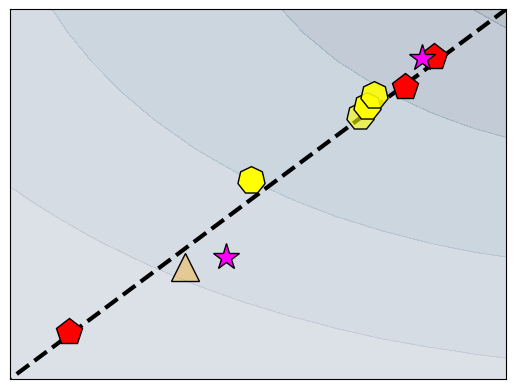

In [176]:
fig, ax = plt.subplots()

# Retas do 0
ax.hlines(0, -7, 7, color="black", alpha=1)
ax.vlines(0, -7, 7, color="black", alpha=1)

# densidade de fundo: onde as 375 amostras se concentram
sns.kdeplot(x=proj_f, y=proj_a, ax=ax, fill=True, color="slategray", alpha=0.5, levels=8, thresh=0.12)

# Reta afim
reta = np.linspace(-7, 7, 1000)
ax.plot(reta, reta, linestyle="--", linewidth=3, color="black", alpha=1)

# centróides de cada rótulo, agora como pares (x, y) reais — sem projeção nenhuma
for idx, classe in enumerate(vf_psm):
    
    alpha_intensidade = (
        int(first_canonical_df[classes_psm[idx]].sum()) * 5 / len(first_canonical_df[classes_psm[idx]])
    )
    if alpha_intensidade < 0.3:
        alpha_intensidade = 0.3
    elif alpha_intensidade > 1:
        alpha_intensidade = 1
    else:
        pass
    
    ax.plot(
        classe,
        vcf_psm[idx],
        zorder=3, 
        markerfacecolor=to_rgba("yellow", alpha_intensidade),
        markeredgecolor="black",
        markersize=20, 
        marker=(7, 0, 0), # Heptágono
    )

for idx, classe in enumerate(vf_ns):

    alpha_intensidade = (
        int(first_canonical_df[classes_ns[idx]].sum()) * 5 / len(first_canonical_df[classes_ns[idx]])
    )
    if alpha_intensidade < 0.3:
        alpha_intensidade = 0.3
    elif alpha_intensidade > 1:
        alpha_intensidade = 1
    else:
        pass
        
    ax.plot(
        classe, 
        vcf_ns[idx],
        zorder=3, 
        markerfacecolor=to_rgba("orange", alpha_intensidade),
        markeredgecolor="black",
        markersize=20, 
        marker="^",
    )

for idx, classe in enumerate(vf_sf):

    alpha_intensidade = (
        int(first_canonical_df[classes_sf[idx]].sum()) * 5 / len(first_canonical_df[classes_sf[idx]])
    )
    if alpha_intensidade < 0.3:
        alpha_intensidade = 0.3
    elif alpha_intensidade > 1:
        alpha_intensidade = 1
    else:
        pass
        
    ax.plot(
        classe, 
        vcf_sf[idx],
        zorder=3, 
        markerfacecolor=to_rgba("red", alpha_intensidade),
        markeredgecolor="black",
        markersize=20, 
        marker="p",
    )

for idx, classe in enumerate(va_sa):

    alpha_intensidade = (
        int(second_canonical_df[classes_sa[idx]].sum()) * 5 / len(second_canonical_df[classes_sa[idx]])
    )
    if alpha_intensidade < 0.3:
        alpha_intensidade = 0.3
    elif alpha_intensidade > 1:
        alpha_intensidade = 1
    else:
        pass
        
    ax.plot(
        classe, 
        vca_sa[idx],
        zorder=3,
        markerfacecolor=to_rgba("magenta", alpha_intensidade),
        markeredgecolor="black",
        markersize=20, 
        marker="*",
    )

ax.set_xlim(-0.62, -0.1)
ax.set_ylim(-0.62, -0.1)
ax.set_xticks([])
ax.set_yticks([])

plt.show()
fig.savefig("grafico_cca_zoom.png", dpi=500)

In [106]:
print(list(dict(sorted(centroides_comuns_f.items(), key=lambda item: item[1])).keys()))
print(list(dict(sorted(centroides_comuns_f.items(), key=lambda item: item[1])).values()))
print("------------------------------------------------------------------------------------------------------------------")
print(list(dict(sorted(centroides_comuns_a.items(), key=lambda item: item[1])).keys()))
print(list(dict(sorted(centroides_comuns_a.items(), key=lambda item: item[1])).values()))
print("------------------------------------------------------------------------------------------------------------------")

['nanotube', 'molybdenum_vacancy', 'nanoparticle', 'few_layer', 'heteroatom_doping', 'metal_clusters', 'heterojunction', 'phase_adjustment', 'nanoflake', 'nanoflower', 'bulk', 'monolayer', 'sulfur_vacancy', 'support', 'quantum_dot']
[-1.5628797528660343, -0.8489849979436671, -0.5536418883931663, -0.4618603679794877, -0.33951913914855497, -0.25033470557593995, -0.23553949182707812, -0.22009329451441187, -0.20921994491756826, -0.16753565906349238, -0.007172775850561156, 0.1281822806223111, 0.18323086132767935, 0.5369846474082471, 0.6776703953058281]
------------------------------------------------------------------------------------------------------------------
['co2rr', 'nrr', 'oer', 'pollutants', 'her']
[-2.910119104809007, -1.6618092942178027, -1.597791089354821, -0.44782043134756533, -0.16868548486755214]
------------------------------------------------------------------------------------------------------------------


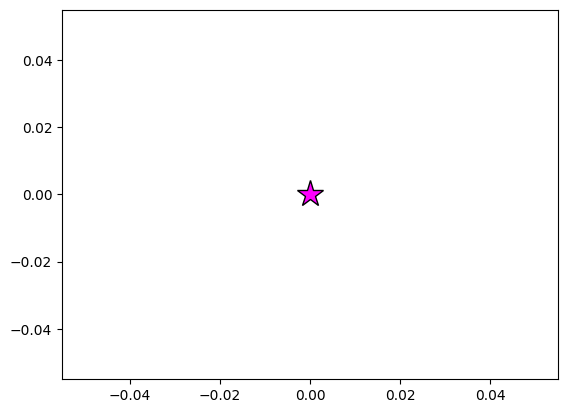

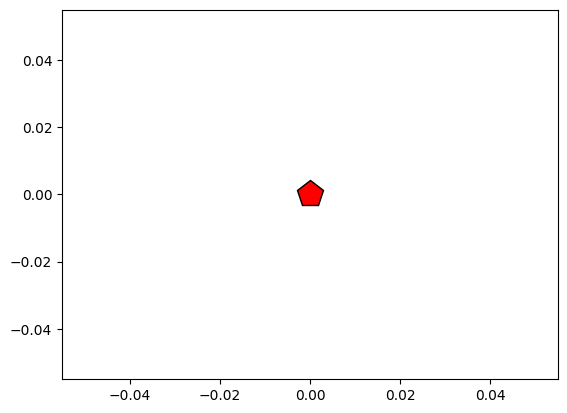

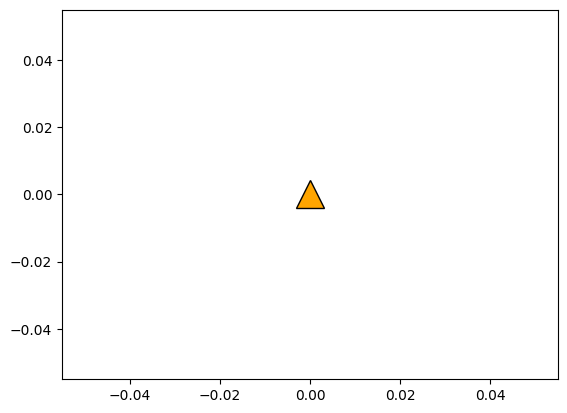

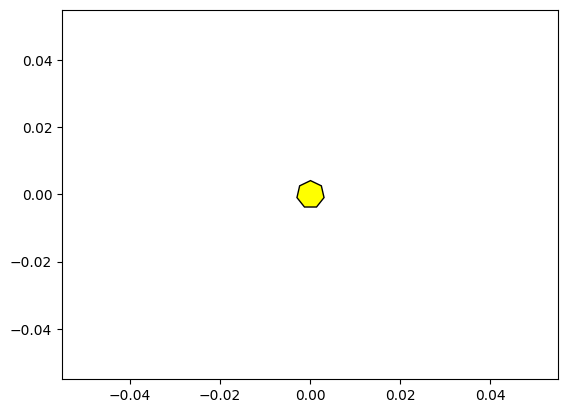

In [126]:
for idx, i in enumerate([("*", "magenta"), ("p", "red"), ("^", "orange"), ((7, 0, 0), "yellow")]):
    fig, ax = plt.subplots()
    ax.plot(0, 0, color=i[1], markeredgecolor="black", markersize=20, marker=i[0])
    plt.show()
    fig.savefig(f"figura_{idx}.png", dpi=500)